In [ ]:
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [1]:
from mcp4cm.bpmn.dataloading import BPMNDataset, load_dataset_from_csv
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


In [2]:
bpmn_dataset = load_dataset(dataset_type=DatasetType.BPMNMODELSET, path='data/bpmnmodelset')


Loading SAP SAM Dataset @ data/bpmnmodelset\sap_sam_2022/models:   0%|          | 0/103 [00:00<?, ?it/s]

Defining file path for saving dataset and loading it later on.

In [3]:
file_path = 'data/bpmnmodelset/processed/culled_models.csv'


In [4]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = False

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'



extract_names_from_models(bpmn_dataset, use_types=use_types)


Extracting names from raw model done.


In [5]:
len(bpmn_dataset)

30312

In [6]:
from mcp4cm.bpmn.data_extraction import (filter_empty_models,
                                         filter_models_by_element_count,
                                         filter_models_by_empty_name_percentage)
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_element_count,
        filter_models_by_empty_name_percentage
    ],
)

print(bpmn_dataset)

Dataset(name=sapsam_2022_bpmn2, models=30312)
Found models with empty names: 808
Filtered out models with element counts outside of 5 and 200: 408
Filtered out models with a empty name percentage higher than 0.5: 14757
Dataset(name=sapsam_2022_bpmn2, models=14339)


In [7]:
from mcp4cm.generic.language_detection import detect_dataset_languages
from mcp4cm.bpmn.data_extraction import extract_model_languages

extract_model_languages(bpmn_dataset, key=key, empty_name=empty_name)


In [8]:
language_dict = detect_dataset_languages(bpmn_dataset)

Language Distribution Across Models:
Language: en, Count: 8750
Language: de, Count: 3590
Language: nl, Count: 101
Language: fr, Count: 207
Language: hr, Count: 146
Language: sl, Count: 128
Language: es, Count: 454
Language: ro, Count: 92
Language: pl, Count: 27
Language: it, Count: 290
Language: pt, Count: 144
Language: el, Count: 35
Language: et, Count: 149
Language: sv, Count: 64
Language: ja, Count: 6
Language: ru, Count: 5
Language: hu, Count: 22
Language: th, Count: 1
Language: so, Count: 1
Language: af, Count: 12
Language: id, Count: 67
Language: fi, Count: 8
Language: tr, Count: 15
Language: da, Count: 7
Language: cs, Count: 4
Language: fa, Count: 1
Language: zh-cn, Count: 1
Language: ca, Count: 2
Language: vi, Count: 2
Language: no, Count: 1
Language: lt, Count: 1
Language: sk, Count: 2
Language: ko, Count: 1
Language: cy, Count: 1
Language: sq, Count: 2


In [9]:
from mcp4cm.generic.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)
language_dict = detect_dataset_languages(english_dataset)

file_path = 'data/bpmnmodelset/processed/english_models.csv'
print(len(english_dataset))
BPMNDataset.to_csv(english_dataset, file_path);


Language Distribution Across Models:
Language: en, Count: 8748
8748


In [10]:
del(english_dataset)

In [11]:
from mcp4cm.bpmn.dataloading import load_dataset_from_csv

file_path = 'data/bpmnmodelset/processed/english_models.csv'
loaded_dataset = load_dataset_from_csv('english_bpmn', fp=file_path)

In [12]:
len(loaded_dataset)

8748


=== Dataset Statistics ===
Duplicate Detection on already computed hashes took 0.00 seconds.
Total number of models: 8748
Total unique files: 3845
Total duplicate files: 4903
Number of duplicate groups: 45


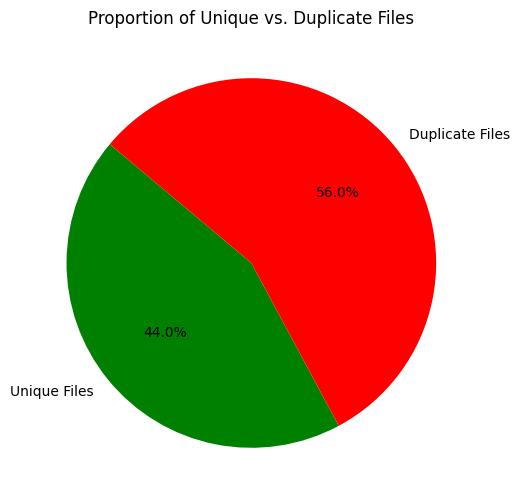

(Dataset(name=english_bpmn_unique, models=3845),
 Dataset(name=english_bpmn_duplicates, models=4903))

In [13]:
from mcp4cm.generic.duplicate_detection import detect_duplicates_by_hash
detect_duplicates_by_hash(loaded_dataset, inplace=False, plt_fig=True, print_results=True)


Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 3466
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 8748
Total unique files: 3299
Total duplicate files: 5449
Number of duplicate groups: 167


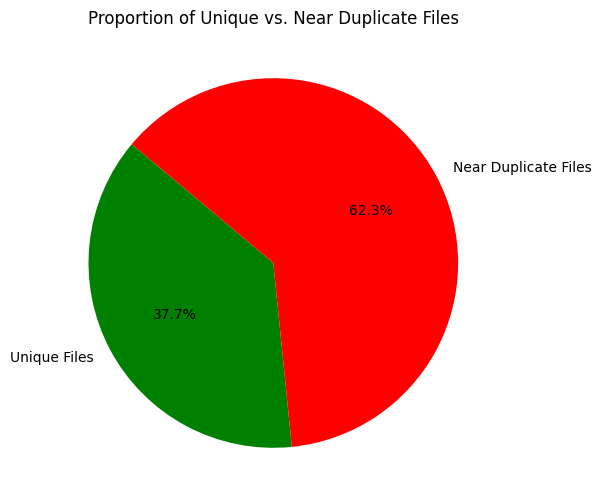

In [14]:
from mcp4cm.generic.duplicate_detection import tfidf_near_duplicate_detector
key = 'names'
_, duplicate_dataset = tfidf_near_duplicate_detector(loaded_dataset,key=key, threshold=0.95, inplace=False, plt_fig=True, print_results=True)

In [15]:
file_path = 'data/bpmnmodelset/processed/english_deduplicated_models.csv'
BPMNDataset.to_csv(loaded_dataset, file_path);

In [16]:
duplicate_file_path = 'data/bpmnmodelset/processed/duplicate_models.csv'
BPMNDataset.to_csv(duplicate_dataset, duplicate_file_path);

In [17]:
duplicate_dataset.models.value_counts('duplicate_group')

duplicate_group
2       1618
0       1615
4       1562
21       102
109       26
        ... 
2833       2
2879       2
2885       2
3040       2
3175       2
Name: count, Length: 167, dtype: int64

In [20]:
print(duplicate_dataset.models.query('duplicate_group == 4').iloc[0].names)
print(duplicate_dataset.models.query('duplicate_group == 2').iloc[1254].names)

['Procure parts', 'empty name', 'no', 'yes', 'Parts in stock', 'empty name', 'Parts out of stock', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'ACME AG', 'Approver', 'ERP-System', 'Approve purchase order', 'Central Purchasing', 'Delivery  Problems', 'Cancelled due to  delivery problems', 'Adjust order status', 'Parts procured', 'Receipt of goods', 'empty name', 'Create vendor', 'Create order template from purchase order', 'Vendor  known?', 'Check purchase order', 'ERP-System', 'Department', 'Retrieve parts from storage', 'Complete a purchase order', 'Parts retrieved from  storage', 'empty name', 'Specify and quantify requirements', 'Parts required']
['Receipt of Goods', 'Passed', 'Failed', 'empty name', 'empty name', 'empty name', 'empty name', 'empty name', 'Yes', 'No', 'empty name', 'empty name', 'empty name', 'empty nam